In [ ]:
import pandas as pd
import os
import kagglehub

# 1. تحميل الداتا (لو مش موجودة هيحملها سريعاً من الكاش)
path = kagglehub.dataset_download("ihmstefanini/industrial-safety-and-health-analytics-database")
file_name = 'IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv'
file_path = os.path.join(path, file_name)

# 2. قراءة الداتا
df = pd.read_csv(file_path)


df.drop(columns=[col for col in df.columns if 'Unnamed' in col], inplace=True)


# 4. تحويل الأنواع لـ category عشان نوفر الـ 65% مساحة اللي عملناها
categorical_cols = ['Countries', 'Local', 'Industry Sector', 'Accident Level',
                    'Potential Accident Level', 'Genre', 'Employee or Third Party', 'Critical Risk']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("--- Data is BACK and Ready, Captain! ---")
df.head()

100%|██████████| 160k/160k [00:00<00:00, 33.8MB/s]

Extracting files...
--- Data is BACK and Ready, Captain! ---


,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description
0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...
1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...
2,2016-01-06 00:00:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...
3,2016-01-08 00:00:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...
4,2016-01-10 00:00:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...


In [ ]:
import os

print(os.listdir(path))

['IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv', 'IHMStefanini_industrial_safety_and_health_database.csv', 'Accidents_Storyline_example.png']


In [ ]:
file_path = os.path.join(path, 'IHMStefanini_industrial_safety_and_health_database.csv')

df = pd.read_csv(file_path)

In [ ]:
df.head()

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee ou Terceiro,Risco Critico
0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed
1,2016-01-02 00:00:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems
2,2016-01-06 00:00:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools
3,2016-01-08 00:00:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others
4,2016-01-10 00:00:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others


In [ ]:
df.head(1)

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee ou Terceiro,Risco Critico
0,2016-01-01 00:00:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed


In [ ]:
df = df.rename(columns={
    'Employee ou Terceiro': 'Employee or Third Party',
    'Risco Critico': 'Critical Risk'
})

In [ ]:
df.columns

Index(['Data', 'Countries', 'Local', 'Industry Sector', 'Accident Level',
       'Potential Accident Level', 'Genre', 'Employee or Third Party',
       'Critical Risk'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
Data,0
Countries,0
Local,0
Industry Sector,0
Accident Level,0
Potential Accident Level,0
Genre,0
Employee or Third Party,0
Critical Risk,0


In [ ]:
df.duplicated().sum()

np.int64(23)

In [ ]:
df[df.duplicated]

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk
42,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
43,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
44,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
45,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
46,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
47,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
48,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
49,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
50,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances
51,2016-02-26 00:00:00,Country_01,Local_06,Metals,I,IV,Male,Third Party (Remote),Pressurized Systems / Chemical Substances


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Data'] = df['Data'].astype(str)

In [ ]:
df['Data'] = df['Data'].str.split(' ').str[0]

In [ ]:
df['Data'] = pd.to_datetime(df['Data'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 416 entries, 0 to 438
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Data                      416 non-null    datetime64[ns]
 1   Countries                 416 non-null    object        
 2   Local                     416 non-null    object        
 3   Industry Sector           416 non-null    object        
 4   Accident Level            416 non-null    object        
 5   Potential Accident Level  416 non-null    object        
 6   Genre                     416 non-null    object        
 7   Employee or Third Party   416 non-null    object        
 8   Critical Risk             416 non-null    object        
dtypes: datetime64[ns](1), object(8)
memory usage: 32.5+ KB


In [ ]:
df['Data'].head(2)

,Data
0,2016-01-01
1,2016-01-02


*Temporal* *Analysis*

**How many accidents occur each year?**

In [ ]:
yearly_accidents=df.groupby(df['Data'].dt.year).size()
print(yearly_accidents)

Data
2016    282
2017    134
dtype: int64


In [ ]:
df['Data'].min(), df['Data'].max()

(Timestamp('2016-01-01 00:00:00'), Timestamp('2017-07-09 00:00:00'))

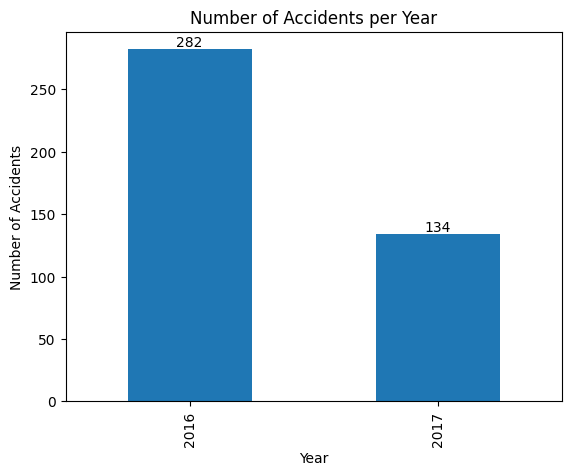

In [ ]:
import matplotlib.pyplot as plt
yearly_accidents.plot(kind='bar')
ax = yearly_accidents.plot(kind='bar')
for i, v in enumerate(yearly_accidents):
    ax.text(i, v + 2, str(v), ha='center')
plt.title("Number of Accidents per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()


The bar chart shows a lower number of accidents in 2017 compared to 2016. However, this is misleading because 2017 data only covers part of the year.

#insight
Although the number of accidents in 2017 appears lower than in 2016, this comparison is misleading because the 2017 data only covers part of the year (until July). When adjusted for time, the accident rate in 2017 is roughly comparable to 2016, indicating no significant improvement.

**Are accidents increasing or decreasing over time**

In [ ]:
acc = df.groupby(df['Data'].dt.to_period('M')).size()
acc

,0
Data,
2016-01,12
2016-02,31
2016-03,34
2016-04,28
2016-05,26
2016-06,30
2016-07,19
2016-08,21
2016-09,24


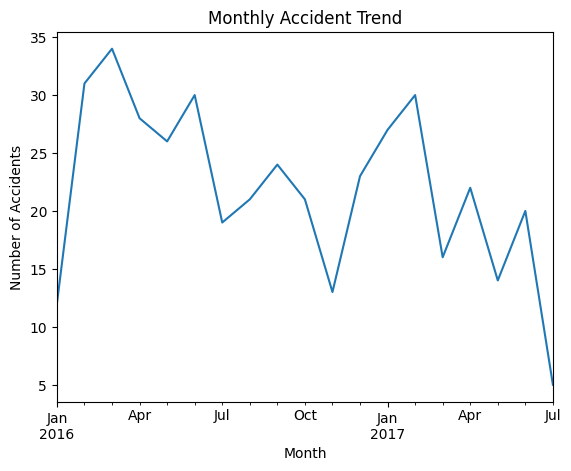

In [ ]:
import matplotlib.pyplot as plt
acc.plot()
plt.title("Monthly Accident Trend")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.show()

#insight
The monthly analysis shows that accident counts fluctuate over time rather than following a clear upward or downward trend. While there is a slight decrease after peak periods, the overall pattern is inconsistent. Additionally, the incomplete data for 2017 limits the ability to draw strong conclusions about long-term trends.


**Which industry has the highest number of accidents?**

In [ ]:
industry_accident=df.groupby("Industry Sector").size()
industry_accident

,0
Industry Sector,
Metals,136
Mining,236
Others,44


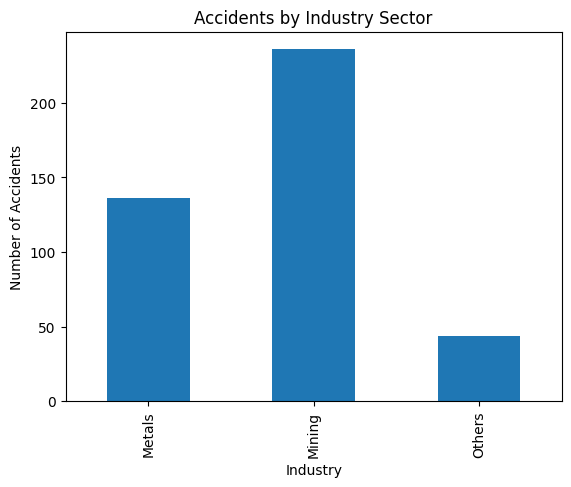

In [ ]:
industry_accident.plot(kind='bar')
plt.title("Accidents by Industry Sector")
plt.xlabel("Industry")
plt.ylabel("Number of Accidents")
plt.show()

#insight
The Mining industry has the highest number of recorded accidents, significantly exceeding both Metals and Other sectors. This suggests that mining operations may involve higher risk activities or exposure to hazardous conditions.

**Which location (country/local) has the highest number of accidents?**

In [ ]:
country_accident=df.groupby("Countries").size()
country_accident

,0
Countries,
Country_01,247
Country_02,131
Country_03,38


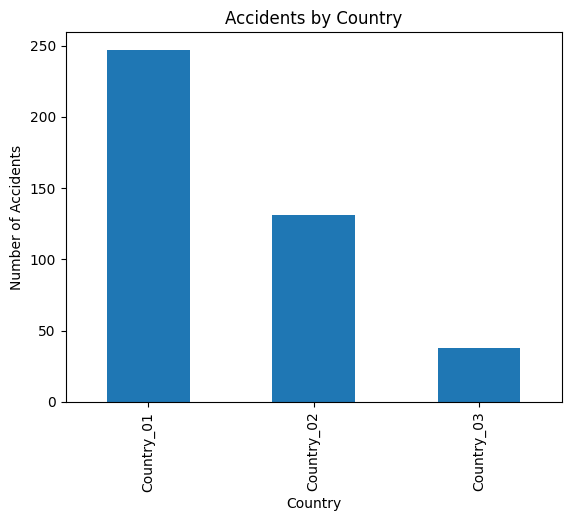

In [ ]:
country_accident.plot(kind='bar')
plt.title("Accidents by Country")
plt.xlabel("Country")
plt.ylabel("Number of Accidents")
plt.show()

#insight
Country_01 has the highest number of recorded accidents, significantly exceeding the other countries. This may indicate higher operational activity or potentially weaker safety controls in that region.

**Which industry has the most severe accidents?**

In [ ]:
sever_accident=df.groupby("Industry Sector")["Accident Level"].value_counts()
sever_accident

Industry Sector  Accident Level
Metals           I                 107
                 II                 12
                 IV                  8
                 III                 7
                 V                   2
Mining           I                 162
                 II                 26
                 IV                 21
                 III                20
                 V                   7
Others           I                  36
                 III                 4
                 II                  2
                 IV                  2
Name: count, dtype: int64

In [ ]:
severe_accidents = df[df['Accident Level'] == 'V']
severe_by_industry = severe_accidents.groupby('Industry Sector').size()
severe_by_industry

,0
Industry Sector,
Metals,2
Mining,7


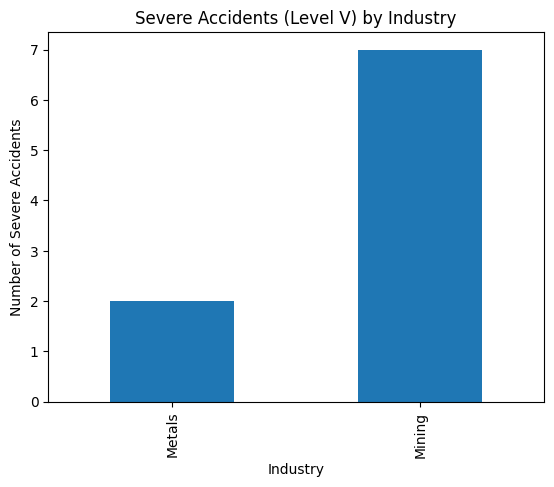

In [ ]:
severe_by_industry.plot(kind='bar')
plt.title("Severe Accidents (Level V) by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Severe Accidents")
plt.show()

#insight
The Mining industry has the highest number of severe (Level V) accidents compared to other sectors. This aligns with its overall higher accident count, suggesting that mining operations may involve higher exposure to high-risk conditions.

**Who is more exposed to accidents: males or females**

In [ ]:
gender_accident=df.groupby("Genre").size()
gender_accident

,0
Genre,
Female,22
Male,394


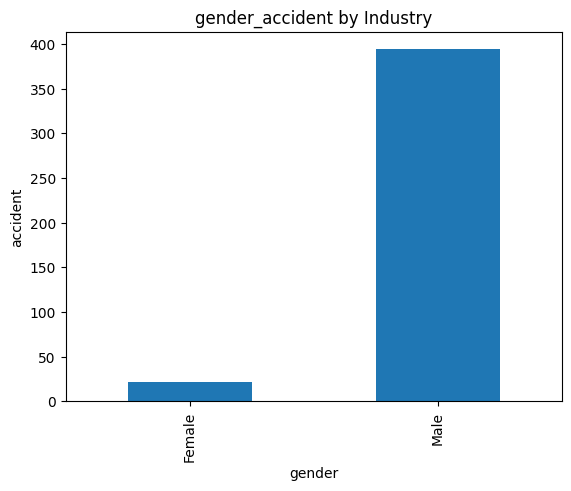

In [ ]:
gender_accident.plot(kind='bar')
plt.title("gender_accident by Industry")
plt.xlabel("gender")
plt.ylabel("accident")
plt.show()

male workers account for the vast majority of recorded accidents, significantly exceeding female workers. However, this result is likely influenced by the higher representation of males in industrial roles, rather than indicating a higher individual risk.

**Who experiences more severe accidents: males or females?**

In [ ]:
severe_gender = df[df['Accident Level'] == 'V']
severe_gender_count = severe_gender.groupby('Genre').size()
severe_gender_count

,0
Genre,
Male,9


#insight
All severe (Level V) accidents were recorded among male workers, with no cases observed for females. However, this result is likely influenced by the significantly higher number of male workers in the dataset, making it difficult to draw conclusions about relative risk between genders.

**Who is more exposed to accidents: employees or third-party workers?**

In [ ]:
employee_accident=df.groupby("Employee or Third Party").size()
employee_accident

,0
Employee or Third Party,
Employee,180
Third Party,182
Third Party (Remote),54


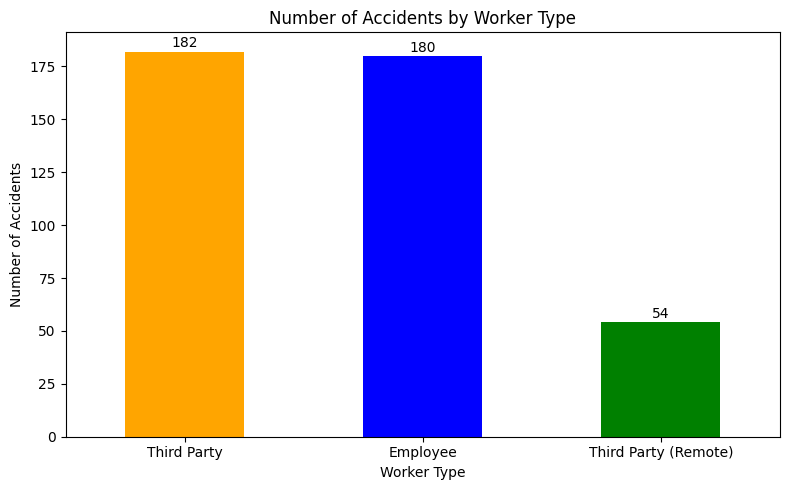

In [ ]:
import matplotlib.pyplot as plt
employee_accident = employee_accident.sort_values(ascending=False)
colors = ['orange', 'blue', 'green']  # Third Party / Employee / Remote (حسب الترتيب)
ax = employee_accident.plot(kind='bar', color=colors, figsize=(8,5))
for i, v in enumerate(employee_accident):
    ax.text(i, v + 2, str(v), ha='center', fontsize=10)
plt.title("Number of Accidents by Worker Type", fontsize=12)
plt.xlabel("Worker Type", fontsize=10)
plt.ylabel("Number of Accidents", fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Third-party workers account for a slightly higher number of accidents compared to employees. When including remote third-party workers, the total number of accidents among third-party personnel becomes significantly higher, suggesting that external workers may be more exposed to operational risks.

In [ ]:
df.head(1)

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed


**Is there a relationship between third-party work and accident severity?**

In [ ]:
severe_worker =df[df['Accident Level']=="V"]
severe_worker_count =severe_worker .groupby("Employee or Third Party").size()
severe_worker_count

,0
Employee or Third Party,
Employee,1
Third Party,6
Third Party (Remote),2


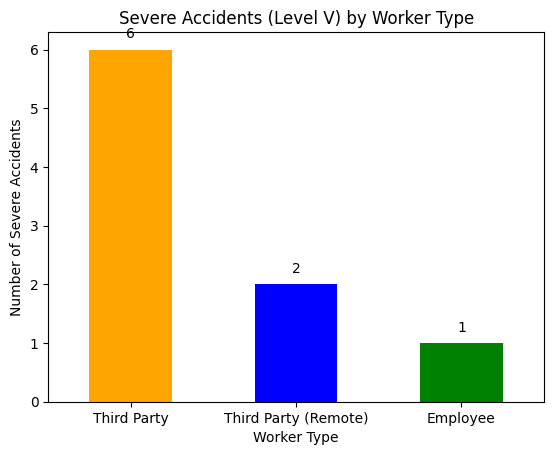

In [ ]:
import matplotlib.pyplot as plt
severe_worker_count = severe_worker_count.sort_values(ascending=False)
ax = severe_worker_count.plot(kind='bar', color=['orange', 'blue', 'green'])
for i, v in enumerate(severe_worker_count):
    ax.text(i, v + 0.2, str(v), ha='center')
plt.title("Severe Accidents (Level V) by Worker Type")
plt.xlabel("Worker Type")
plt.ylabel("Number of Severe Accidents")
plt.xticks(rotation=0)
plt.show()

#insight
Third-party workers account for the majority of severe (Level V) accidents, significantly exceeding employees. This suggests that external workers may face higher exposure to critical risks, possibly due to differences in training, supervision, or familiarity with the work environment.

#important insight
This is a key safety concern that may require targeted training and stricter supervision for third-party workers.

**What are the most common critical risks, and how do they relate to accident severity?**

In [ ]:
all_risks = df.groupby("Critical Risk").size().sort_values(ascending=False)
all_risks

,0
Critical Risk,
Others,229
Pressed,24
Manual Tools,20
Chemical substances,17
Cut,14
Projection,13
Venomous Animals,13
Fall,9
Vehicles and Mobile Equipment,8


In [ ]:

critcal=severe_worker.groupby("Critical Risk").size()
critcal

,0
Critical Risk,
Fall,1
Not applicable,1
Others,3
Power lock,2
Vehicles and Mobile Equipment,1
remains of choco,1


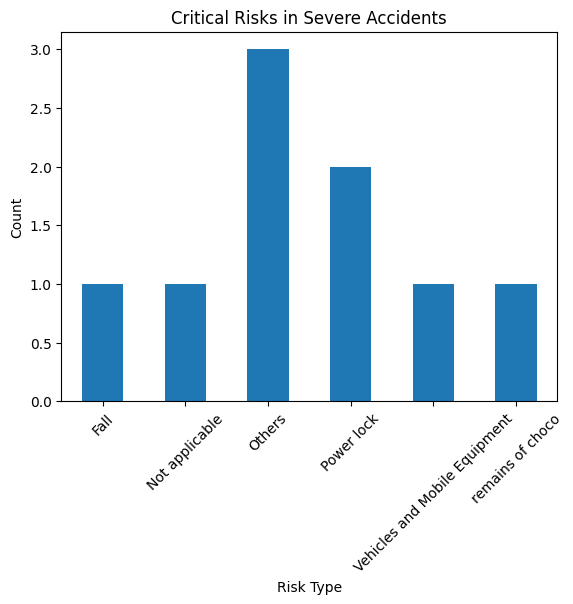

In [ ]:
critcal.plot(kind='bar')
plt.title("Critical Risks in Severe Accidents")
plt.xlabel("Risk Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#insight
The most common risks are not necessarily the most severe. While risks such as “Pressed” and “Manual Tools” occur frequently, severe accidents are more associated with risks like “Power lock,” “Falls,” and “Vehicles.” This indicates that less frequent hazards may carry higher potential for critical outcomes.

Safety efforts لازم تركز مش بس على الأكثر تكرارًا…
لكن على الأكثر خطورة حتى لو قليلة

**total accident for each indutry**

In [ ]:
total_industry = df.groupby("Industry Sector").size()

**severe_industry **


In [ ]:
severe_industry = df[df['Accident Level'] == 'V'].groupby("Industry Sector").size()

**severity_ratio**

In [ ]:
severity_ratio = (severe_industry / total_industry).sort_values(ascending=False)
severity_ratio

,0
Industry Sector,
Mining,0.029661
Metals,0.014706
Others,NaN


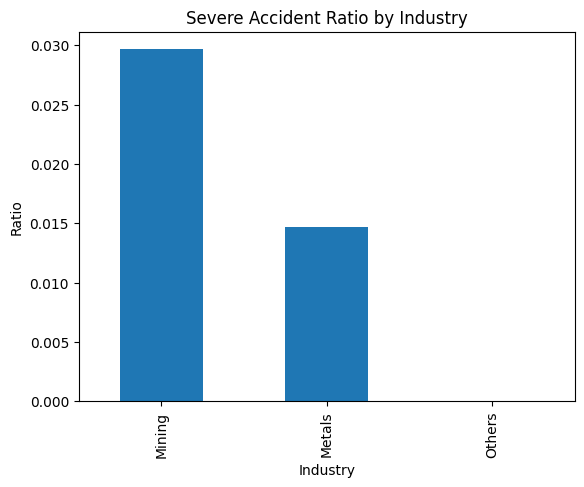

In [ ]:
severity_ratio.plot(kind='bar')
plt.title("Severe Accident Ratio by Industry")
plt.xlabel("Industry")
plt.ylabel("Ratio")
plt.show()

#insight
After normalizing by total accidents, the Mining industry still shows a higher proportion of severe accidents (~3%) compared to Metals (~1.5%). However, the difference is less pronounced than suggested by raw counts, highlighting the importance of using relative measures for accurate risk assessment.

📊 Industrial Safety Analysis Report
🧾 1. Project Overview
English:

This project analyzes industrial accident data to understand patterns, identify high-risk areas, and provide insights to improve workplace safety.

عربي:

يهدف هذا المشروع إلى تحليل بيانات الحوادث الصناعية لفهم الأنماط، وتحديد مناطق الخطورة، وتقديم توصيات لتحسين السلامة في بيئة العمل.

🎯 2. Objectives
Analyze accident trends over time
Identify high-risk industries and locations
Understand the impact of human factors
Detect the most critical risks
Evaluate accident severity patterns
📦 3. Data Description

The dataset includes:

Date of accident
Industry sector
Country / location
Worker type (Employee / Third Party)
Gender
Accident severity
Critical risk
🧹 4. Data Cleaning
Removed duplicate records
Converted date column to datetime
Standardized column names
Handled categorical variables
📊 5. Key Findings
📅 5.1 Time Analysis
English:

Accidents appear lower in 2017 compared to 2016, but this is misleading because 2017 data is incomplete (only up to July). Monthly analysis shows fluctuations without a clear trend.

عربي:

يبدو أن الحوادث أقل في 2017 مقارنة بـ 2016، لكن هذا مضلل لأن بيانات 2017 غير مكتملة. التحليل الشهري يظهر تذبذبًا دون اتجاه واضح.

🏭 5.2 Industry Analysis
Mining has the highest number of accidents
Metals comes second
Others has the lowest
Insight:

Mining operations involve higher exposure to risks.

📍 5.3 Location Analysis
Country_01 has the highest number of accidents
Insight:

This may indicate higher activity or weaker safety controls.

👷 5.4 Worker Type Analysis
Third-party workers have more accidents than employees
When including remote workers, the gap becomes larger
Insight:

External workers may be more exposed to risks due to:

Less training
Less supervision
⚠️ 5.5 Severity Analysis
Mining has the highest number of severe accidents
After normalization:
Mining ≈ 3%
Metals ≈ 1.5%
Insight:

Mining is still riskier, but the difference is smaller when using ratios.

👨‍🔧 5.6 Gender Analysis
Males account for the vast majority of accidents
No severe accidents recorded for females
Insight:

This is likely due to workforce imbalance, not necessarily higher risk.

🔥 5.7 Critical Risk Analysis
Most Common Risks:
Others (non-specific)
Pressed
Manual Tools
Most Severe Risks:
Power lock
Falls
Vehicles
Insight:

The most frequent risks are not the most dangerous.

💡 6. Key Insights
English:
High-frequency risks are not always high-severity risks
Third-party workers are more exposed to severe accidents
Mining remains the most critical sector, even after normalization
Data quality issues exist (large “Others” category)
عربي:
المخاطر الأكثر تكرارًا ليست بالضرورة الأكثر خطورة
العمالة الخارجية أكثر تعرضًا للحوادث الخطيرة
قطاع التعدين هو الأكثر خطورة حتى بعد استخدام النسب
توجد مشكلة في جودة البيانات (وجود فئة "Others")
🚨 7. Recommendations
English:
Improve training programs for third-party workers
Focus safety measures on high-severity risks, not just frequent ones
Improve risk classification to reduce “Others” category
Monitor mining operations more closely
عربي:
تحسين تدريب العمالة الخارجية
التركيز على المخاطر عالية الخطورة وليس فقط الشائعة
تحسين تصنيف البيانات لتقليل فئة "Others"
زيادة الرقابة على عمليات التعدين
🏁 8. Conclusion
English:

This analysis highlights the importance of going beyond simple counts and using normalized metrics to better understand risk patterns and make informed decisions.

عربي:

يوضح هذا التحليل أهمية الاعتماد على النسب وليس الأعداد فقط لفهم المخاطر بشكل أدق واتخاذ قرارات صحيحة.

In [ ]:
df

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others
...,...,...,...,...,...,...,...,...,...
434,2017-07-04,Country_01,Local_04,Mining,I,III,Male,Third Party,Others
435,2017-07-04,Country_01,Local_03,Mining,I,II,Female,Employee,Others
436,2017-07-05,Country_02,Local_09,Metals,I,II,Male,Employee,Venomous Animals
437,2017-07-06,Country_02,Local_05,Metals,I,II,Male,Employee,Cut


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# احفظ الـ df على Drive
df.to_excel("/content/drive/MyDrive/my_project.xlsx", index=False)

print("✅ اتحفظ على Google Drive!")

Mounted at /content/drive
✅ اتحفظ على Google Drive!
